In [2]:
import pandas as pd 
import numpy as np 


In [4]:
df=pd.read_csv("/kaggle/input/datasets/rajpratapsinghsengar/new-dataset/dataset.csv")

In [5]:
df.shape

(404800, 27)

In [6]:
df.head()

,Unnamed: 0,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [7]:
df.drop('Unnamed: 0',inplace=True,axis=1)

In [8]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404797 non-null  float64
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          402807 non-null  float64
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  school_fees             404800 non-null  float64
 12  college_fees            404800 non-null  float64
 13  travel_expenses         404800 non-null  float64
 14  groceries_utilities 

In [10]:
from sklearn.model_selection import train_test_split
x=df.drop(['emi_eligibility', 'max_monthly_emi'],axis=1)
y=df['max_monthly_emi']

In [11]:
x.shape, y.shape

((404800, 24), (404800,))

In [12]:
x.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7


In [13]:
y.head()

0      500.0
1      700.0
2    27775.0
3    16170.0
4      500.0
Name: max_monthly_emi, dtype: float64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape,y_train.shape

((323840, 24), (323840,))

In [16]:
X_test.shape,y_test.shape

((80960, 24), (80960,))

In [17]:

numerical_with_nan=[feature for feature in X_train.columns if X_train[feature].isnull().sum()>1 and X_train[feature].dtypes!='object']


for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(X_train[feature].isnull().mean(),4)))

age: 0.0% missing value
monthly_salary: 0.0049% missing value
monthly_rent: 0.006% missing value
credit_score: 0.0059% missing value
bank_balance: 0.006% missing value
emergency_fund: 0.0058% missing value


In [18]:
for feature in numerical_with_nan:
    print(X_train[feature].dtypes)

float64
float64
float64
float64
float64
float64


In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_train[numerical_with_nan] = imputer.fit_transform(
    X_train[numerical_with_nan]
)

X_test[numerical_with_nan] = imputer.transform(
    X_test[numerical_with_nan]
)

In [20]:
categorical_with_nan=[feature for feature in X_train.columns if X_train[feature].isnull().sum()>1 and X_train[feature].dtypes=='object']

In [21]:
categorical_with_nan

['education']

In [22]:
for feature in categorical_with_nan:
    print(
        f"{feature}: "
        f"{np.around(X_train[feature].isnull().mean() * 100, 4)}% missing"
    )

education: 0.5926% missing


In [24]:
X_train[categorical_with_nan].dtypes

education    object
dtype: object

In [25]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[["education"]] = cat_imputer.fit_transform(
    X_train[["education"]]
)

X_test[["education"]] = cat_imputer.transform(
    X_test[["education"]]
)

In [26]:
X_train.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
dtype: int64

In [27]:
X_test.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
dtype: int64

In [28]:
numerical_features=[feature for feature in X_train.columns if  X_train[feature].dtypes!='object']

In [29]:
for feature in numerical_features:
    print(X_train[feature].dtypes)

float64
float64
float64
float64
int64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
int64


In [30]:
len(numerical_features)

16

In [31]:
skewed_features = []

for feature in numerical_features:
    skewness = X_train[feature].skew()

    if abs(skewness) > 0.5:
        skewed_features.append(feature)
        print(f"{feature}: {skewness:.4f}")

age: 0.6516
monthly_salary: 4.8597
years_of_employment: 2.1470
monthly_rent: 1.6169
school_fees: 0.5833
college_fees: 1.5386
travel_expenses: 1.3551
groceries_utilities: 1.2278
other_monthly_expenses: 1.4027
current_emi_amount: 1.7843
credit_score: -1.1120
bank_balance: 1.4221
emergency_fund: 1.8006
requested_amount: 1.3838
requested_tenure: 0.9180


In [32]:
X_train_original = X_train.copy()
X_train_log = X_train.copy()
X_train_sqrt = X_train.copy()
X_train_yj = X_train.copy()

In [40]:
for feature in skewed_features:
    X_train_log[feature] = np.log1p(X_train_log[feature])

In [41]:
for feature in skewed_features:
    X_train_sqrt[feature] = np.sqrt(X_train_sqrt[feature])

In [42]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(
    method='yeo-johnson',
    standardize=False
)

X_train_yj[skewed_features] = pt.fit_transform(
    X_train_yj[skewed_features]
)

In [43]:
skewness_comparison = pd.DataFrame({
    'Original': X_train_original[skewed_features].skew(),
    'Log1p': X_train_log[skewed_features].skew(),
    'Square Root': X_train_sqrt[skewed_features].skew(),
    'Yeo-Johnson': X_train_yj[skewed_features].skew()
})

skewness_comparison

,Original,Log1p,Square Root,Yeo-Johnson
age,0.651630,0.199959,0.385486,0.007024
monthly_salary,4.859743,-0.333613,0.736847,0.023744
years_of_employment,2.147007,-0.322676,0.452837,-0.058909
monthly_rent,1.616863,0.377212,0.471887,0.376592
school_fees,0.583321,-0.173331,-0.079099,-0.166935
college_fees,1.538644,1.029255,1.078136,1.028757
travel_expenses,1.355141,-0.401018,0.189645,-0.011366
groceries_utilities,1.227838,-0.358157,0.159531,-0.010881
other_monthly_expenses,1.402663,-0.442697,0.182998,-0.013012
current_emi_amount,1.784329,0.415298,0.521453,0.414463


In [44]:
abs_skewness = skewness_comparison.abs()

abs_skewness

,Original,Log1p,Square Root,Yeo-Johnson
age,0.651630,0.199959,0.385486,0.007024
monthly_salary,4.859743,0.333613,0.736847,0.023744
years_of_employment,2.147007,0.322676,0.452837,0.058909
monthly_rent,1.616863,0.377212,0.471887,0.376592
school_fees,0.583321,0.173331,0.079099,0.166935
college_fees,1.538644,1.029255,1.078136,1.028757
travel_expenses,1.355141,0.401018,0.189645,0.011366
groceries_utilities,1.227838,0.358157,0.159531,0.010881
other_monthly_expenses,1.402663,0.442697,0.182998,0.013012
current_emi_amount,1.784329,0.415298,0.521453,0.414463


In [45]:
best_transformation = abs_skewness.idxmin(axis=1)

result = pd.DataFrame({
    'Best Transformation': best_transformation,
    'Best |Skewness|': abs_skewness.min(axis=1)
})

result

,Best Transformation,Best |Skewness|
age,Yeo-Johnson,0.007024
monthly_salary,Yeo-Johnson,0.023744
years_of_employment,Yeo-Johnson,0.058909
monthly_rent,Yeo-Johnson,0.376592
school_fees,Square Root,0.079099
college_fees,Yeo-Johnson,1.028757
travel_expenses,Yeo-Johnson,0.011366
groceries_utilities,Yeo-Johnson,0.010881
other_monthly_expenses,Yeo-Johnson,0.013012
current_emi_amount,Yeo-Johnson,0.414463


In [46]:
yeo_johnson_features = [
    'age',
    'monthly_salary',
    'years_of_employment',
    'monthly_rent',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'current_emi_amount',
    'credit_score',
    'bank_balance',
    'emergency_fund',
    'requested_amount',
    'requested_tenure'
]

sqrt_features = [
    'school_fees'
]

In [47]:
pt = PowerTransformer(
    method='yeo-johnson',
    standardize=False
)

X_train[yeo_johnson_features] = pt.fit_transform(
    X_train[yeo_johnson_features]
)

X_test[yeo_johnson_features] = pt.transform(
    X_test[yeo_johnson_features]
)

X_train['school_fees'] = np.sqrt(X_train['school_fees'])
X_test['school_fees'] = np.sqrt(X_test['school_fees'])

In [48]:
for feature in numerical_features:
    print(X_train[feature].skew())

0.05264688390943092
0.003341579936559153
0.07577809361297111
0.38151298002992384
0.021898989703657702
0.12947435615599817
1.0289622119891035
-0.007670554681116156
-0.00796765832389973
-0.009289933988961118
0.4195925770566364
0.6502089931942617
-0.030161200361907736
-0.019382606374866777
-0.020448472290481877
-0.029624077613872143


In [49]:
categorical_features=[feature for feature in X_train.columns if  X_train[feature].dtypes=='object']

In [50]:
for feature in categorical_features:
    print(X_train[feature].dtypes)

object
object
object
object
object
object
object
object


In [51]:
len(categorical_features)

8

In [52]:
for feature in categorical_features :
    print(f"Total Number of categories in {feature}  = {len(X_train[feature].unique())}")

Total Number of categories in gender  = 2
Total Number of categories in marital_status  = 2
Total Number of categories in education  = 4
Total Number of categories in employment_type  = 3
Total Number of categories in company_type  = 5
Total Number of categories in house_type  = 3
Total Number of categories in existing_loans  = 2
Total Number of categories in emi_scenario  = 5


In [53]:
categorical_features

['gender',
 'marital_status',
 'education',
 'employment_type',
 'company_type',
 'house_type',
 'existing_loans',
 'emi_scenario']

In [54]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)


In [55]:

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [56]:
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

In [57]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

In [58]:
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

In [59]:
X_train_final = pd.concat(
    [X_train_num, X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_encoded],
    axis=1
)

In [60]:
print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test_final.shape)

X_train_final.head()

X_train shape: (323840, 34)
X_test shape: (80960, 34)


,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,...,company_type_Mid-size,company_type_Small,company_type_Startup,house_type_Own,house_type_Rented,existing_loans_Yes,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI
155851,1.279462,11.355945,1.725047,-0.000000,3,0.000000,2.896040,13.016917,15.986374,16.159507,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
334888,1.307405,12.303126,1.228668,5.733825,2,70.710678,-0.000000,15.563998,20.532403,19.348771,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
287459,1.292244,11.624635,1.258685,-0.000000,3,101.488916,2.882868,13.682733,16.691774,15.911484,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
223619,1.307405,11.645839,1.589854,-0.000000,2,0.000000,-0.000000,13.198233,16.770834,13.655224,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
115669,1.279462,12.319060,0.384740,-0.000000,2,0.000000,-0.000000,14.790470,18.994132,18.730903,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [61]:
from sklearn.feature_selection import VarianceThreshold

# Any feature with variance below this threshold is considered constant/near-constant
selector_var = VarianceThreshold(threshold=0.0)
selector_var.fit(X_train_final)

constant_features = X_train_final.columns[~selector_var.get_support()]
print("Constant / near-constant features to drop:", list(constant_features))

X_train_v1 = X_train_final.drop(columns=constant_features)
X_test_v1 = X_test_final.drop(columns=constant_features)

print("Shape after removing constant features:", X_train_v1.shape)


Constant / near-constant features to drop: []
Shape after removing constant features: (323840, 34)


In [62]:
corr_matrix = X_train_v1.corr().abs()

# Keep only the upper triangle to avoid dropping both features in a pair
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

CORR_THRESHOLD = 0.90
high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > CORR_THRESHOLD)
]

print(f"Highly correlated features to drop (threshold={CORR_THRESHOLD}):", high_corr_features)

X_train_v2 = X_train_v1.drop(columns=high_corr_features)
X_test_v2 = X_test_v1.drop(columns=high_corr_features)

print("Shape after removing correlated features:", X_train_v2.shape)


Highly correlated features to drop (threshold=0.9): ['emergency_fund', 'house_type_Rented', 'existing_loans_Yes']
Shape after removing correlated features: (323840, 31)


In [ ]:
X_train_v2.to_parquet("/kaggle/working/X_train_v2.parquet", index=False)
X_test_v2.to_parquet("/kaggle/working/X_test_v2.parquet", index=False)
y_train.to_frame("emi_eligibility").to_parquet(
    "/kaggle/working/y_train.parquet",
    index=False
)

y_test.to_frame("emi_eligibility").to_parquet(
    "/kaggle/working/y_test.parquet",
    index=False
)

In [1]:
import pandas as pd 

In [6]:
X_train_v2 = pd.read_parquet("/kaggle/input/datasets/rajpratapsinghsengar/emi-dataset/X_train_v2.parquet")
X_test_v2 = pd.read_parquet("/kaggle/input/datasets/rajpratapsinghsengar/emi-dataset/X_test_v2.parquet")

y_train = pd.read_parquet("/kaggle/input/datasets/rajpratapsinghsengar/emi-dataset/y_train.parquet").iloc[:, 0]
y_test = pd.read_parquet("/kaggle/input/datasets/rajpratapsinghsengar/emi-dataset/y_test.parquet").iloc[:, 0]

In [8]:
print("X_train_v2 shape:", X_train_v2.shape)
print("X_test_v2 shape:", X_test_v2.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_v2 shape: (323840, 31)
X_test_v2 shape: (80960, 31)
y_train shape: (323840,)
y_test shape: (80960,)


In [9]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Calculate Mutual Information
mi_scores = mutual_info_regression(
    X_train_v2,
    y_train,
    random_state=42
)

# Create a DataFrame
mi_df = pd.DataFrame({
    "Feature": X_train_v2.columns,
    "MI_Score": mi_scores
})

# Sort from highest to lowest
mi_df = mi_df.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

print(mi_df)

                             Feature  MI_Score
0                 current_emi_amount  0.266753
1                     monthly_salary  0.213063
2                groceries_utilities  0.151768
3      employment_type_Self-employed  0.137613
4                    travel_expenses  0.120741
5                       bank_balance  0.111744
6            employment_type_Private  0.107773
7                       monthly_rent  0.105563
8                       college_fees  0.101269
9             other_monthly_expenses  0.090630
10                      credit_score  0.089479
11                       school_fees  0.062314
12               years_of_employment  0.038415
13                    house_type_Own  0.032574
14                       family_size  0.019886
15            education_Professional  0.015585
16             education_High School  0.012390
17             marital_status_Single  0.009505
18                  requested_amount  0.007233
19                               age  0.005783
20           

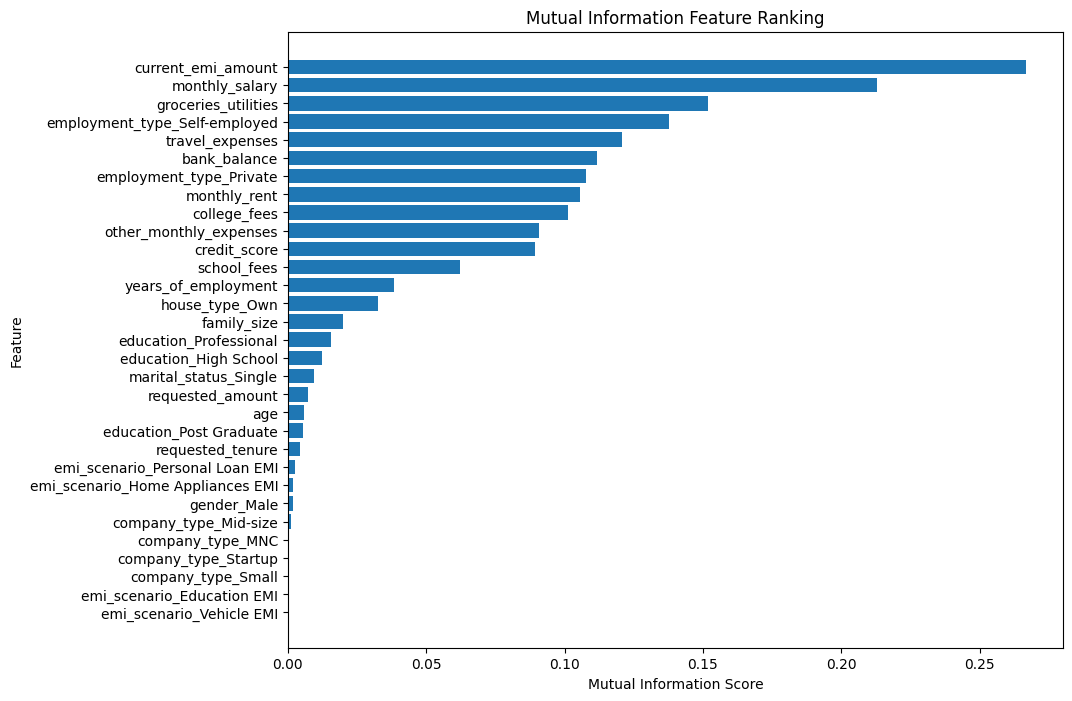

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    mi_df["Feature"],
    mi_df["MI_Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Feature Ranking")

plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Create Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

# Train Random Forest
rf.fit(X_train_v2, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train_v2.columns,
    "Importance": rf.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance)



                             Feature  Importance
0                     monthly_salary    0.365444
1                 current_emi_amount    0.196045
2                       monthly_rent    0.152646
3                       college_fees    0.086482
4                        school_fees    0.053449
5                groceries_utilities    0.040005
6                       credit_score    0.031930
7                       bank_balance    0.023876
8             other_monthly_expenses    0.019042
9                    travel_expenses    0.009227
10               years_of_employment    0.007190
11                    house_type_Own    0.002880
12                  requested_amount    0.002612
13                  requested_tenure    0.002307
14           employment_type_Private    0.001166
15                               age    0.000959
16                       family_size    0.000851
17     employment_type_Self-employed    0.000408
18                       gender_Male    0.000359
19             compa

In [13]:

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

In [14]:
# ============================================================
# 2. DEFINE FEATURE SETS
# ============================================================

feature_counts = [5, 10, 15, 20, 25]


# ============================================================
# 3. 5-FOLD CROSS VALIDATION
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. STORE RESULTS
# ============================================================

results = []


# ============================================================
# 5. TEST EACH FEATURE SET
# ============================================================

for n_features in feature_counts:

    print("\n" + "=" * 60)
    print(f"Testing Top {n_features} Features")
    print("=" * 60)

    # Get top N features
    selected_features = (
        feature_importance
        .head(n_features)["Feature"]
        .tolist()
    )

    print("Selected Features:")
    print(selected_features)

    # Select features
    X_selected = X_train_v2[
        selected_features
    ]

    # Create model
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=2
    )

    # Cross validation
    cv_result = cross_validate(
        model,
        X_selected,
        y_train,
        cv=cv,
        scoring={
            "R2": "r2",
            "RMSE": "neg_root_mean_squared_error",
            "MAE": "neg_mean_absolute_error"
        },
        n_jobs=2,
        return_train_score=False
    )

    # Convert negative metrics to positive
    mean_r2 = cv_result["test_R2"].mean()
    std_r2 = cv_result["test_R2"].std()

    mean_rmse = (
        -cv_result["test_RMSE"].mean()
    )

    std_rmse = (
        cv_result["test_RMSE"].std()
    )

    mean_mae = (
        -cv_result["test_MAE"].mean()
    )

    std_mae = (
        cv_result["test_MAE"].std()
    )

    # Store result
    results.append({
        "Number_of_Features": n_features,
        "Mean_R2": mean_r2,
        "Std_R2": std_r2,
        "Mean_RMSE": mean_rmse,
        "Std_RMSE": std_rmse,
        "Mean_MAE": mean_mae,
        "Std_MAE": std_mae
    })

    print(
        f"Mean R²   : {mean_r2:.4f}"
    )

    print(
        f"Mean RMSE : {mean_rmse:.2f}"
    )

    print(
        f"Mean MAE  : {mean_mae:.2f}"
    )


# ============================================================
# 6. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n\n")
print("=" * 80)
print("FEATURE SELECTION CROSS-VALIDATION RESULTS")
print("=" * 80)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 7. FIND BEST FEATURE SET
# ============================================================

best_row = results_df.loc[
    results_df["Mean_R2"].idxmax()
]

best_n_features = int(
    best_row["Number_of_Features"]
)

print("\n" + "=" * 60)
print("BEST FEATURE SET")
print("=" * 60)

print(
    "Number of Features:",
    best_n_features
)

print(
    "Mean CV R²:",
    best_row["Mean_R2"]
)

print(
    "Mean CV RMSE:",
    best_row["Mean_RMSE"]
)

print(
    "Mean CV MAE:",
    best_row["Mean_MAE"]
)


# ============================================================
# 8. FINAL SELECTED FEATURES
# ============================================================

final_features = (
    feature_importance
    .head(best_n_features)["Feature"]
    .tolist()
)

print("\nFinal Selected Features:")

for i, feature in enumerate(
    final_features,
    start=1
):
    print(
        f"{i}. {feature}"
    )


# ============================================================
# 9. CREATE FINAL SELECTED DATASETS
# ============================================================

X_train_selected = X_train_v2[
    final_features
]

X_test_selected = X_test_v2[
    final_features
]

print("\n" + "=" * 60)
print("FINAL DATASET SHAPES")
print("=" * 60)

print(
    "X_train_selected:",
    X_train_selected.shape
)

print(
    "X_test_selected:",
    X_test_selected.shape
)


Testing Top 5 Features
Selected Features:
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees']
Mean R²   : 0.8409
Mean RMSE : 3093.03
Mean MAE  : 1820.46

Testing Top 10 Features
Selected Features:
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees', 'groceries_utilities', 'credit_score', 'bank_balance', 'other_monthly_expenses', 'travel_expenses']


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mean R²   : 0.9577
Mean RMSE : 1594.21
Mean MAE  : 894.31

Testing Top 15 Features
Selected Features:
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees', 'groceries_utilities', 'credit_score', 'bank_balance', 'other_monthly_expenses', 'travel_expenses', 'years_of_employment', 'house_type_Own', 'requested_amount', 'requested_tenure', 'employment_type_Private']


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mean R²   : 0.9625
Mean RMSE : 1500.96
Mean MAE  : 839.06

Testing Top 20 Features
Selected Features:
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees', 'groceries_utilities', 'credit_score', 'bank_balance', 'other_monthly_expenses', 'travel_expenses', 'years_of_employment', 'house_type_Own', 'requested_amount', 'requested_tenure', 'employment_type_Private', 'age', 'family_size', 'employment_type_Self-employed', 'gender_Male', 'company_type_Mid-size']
Mean R²   : 0.9622
Mean RMSE : 1507.16
Mean MAE  : 843.07

Testing Top 25 Features
Selected Features:
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees', 'groceries_utilities', 'credit_score', 'bank_balance', 'other_monthly_expenses', 'travel_expenses', 'years_of_employment', 'house_type_Own', 'requested_amount', 'requested_tenure', 'employment_type_Private', 'age', 'family_size', 'employment_type_Self-employed', 'gender_Male', 'company_type_Mid-size', 'company_type_

In [17]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor

# All 31 features
selected_features = feature_importance["Feature"].tolist()

X_selected = X_train_v2[selected_features]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_result = cross_validate(
    model,
    X_selected,
    y_train,
    cv=cv,
    scoring={
        "R2": "r2",
        "RMSE": "neg_root_mean_squared_error",
        "MAE": "neg_mean_absolute_error"
    },
    n_jobs=2
)

mean_r2 = cv_result["test_R2"].mean()
std_r2 = cv_result["test_R2"].std()

mean_rmse = -cv_result["test_RMSE"].mean()
std_rmse = cv_result["test_RMSE"].std()

mean_mae = -cv_result["test_MAE"].mean()
std_mae = cv_result["test_MAE"].std()

print("=" * 60)
print("TOP 31 FEATURES")
print("=" * 60)

print(f"Mean R²   : {mean_r2:.6f}")
print(f"Std R²    : {std_r2:.6f}")
print(f"Mean RMSE : {mean_rmse:.2f}")
print(f"Std RMSE  : {std_rmse:.2f}")
print(f"Mean MAE  : {mean_mae:.2f}")
print(f"Std MAE   : {std_mae:.2f}")

TOP 31 FEATURES
Mean R²   : 0.961770
Std R²    : 0.000447
Mean RMSE : 1516.39
Std RMSE  : 11.36
Mean MAE  : 850.36
Std MAE   : 3.40


In [19]:
X_train_selected

,monthly_salary,current_emi_amount,monthly_rent,college_fees,school_fees,groceries_utilities,credit_score,bank_balance,other_monthly_expenses,travel_expenses,years_of_employment,house_type_Own,requested_amount,requested_tenure,employment_type_Private
155851,11.355942,0.00000,0.000000,2.896040,0.000000,15.986378,8870.229995,72.648651,16.159507,13.016915,1.725047,1.0,33.701208,6.599322,0.0
334888,12.303122,0.00000,5.733824,0.000000,70.710678,20.532410,9352.868708,86.081885,19.348771,15.563995,1.228668,0.0,23.382154,4.198533,1.0
287459,11.624631,5.02807,0.000000,2.882868,101.488916,16.691779,8959.019531,78.642709,15.911484,13.682730,1.258685,0.0,28.833377,3.565146,0.0
223619,11.645836,0.00000,0.000000,0.000000,0.000000,16.770839,7605.159938,79.071382,13.655223,13.198230,1.589854,0.0,28.865346,5.660294,0.0
115669,12.319057,5.43397,0.000000,0.000000,0.000000,18.994138,5940.729275,94.722951,18.730903,14.790467,0.384740,1.0,24.213814,4.801927,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,12.503142,0.00000,0.000000,0.000000,0.000000,20.258627,8852.504393,102.019887,19.662947,16.348890,0.929530,1.0,28.670226,5.983526,1.0
365838,10.571468,0.00000,0.000000,2.843963,90.000000,15.680158,7826.087935,46.083751,14.613913,12.921768,1.672008,0.0,25.457931,5.300018,1.0
131932,12.648550,0.00000,5.741474,0.000000,103.923048,20.367277,8623.056385,73.586937,19.007659,17.259728,1.287100,0.0,19.268006,4.801927,1.0
146867,12.237147,0.00000,0.000000,0.000000,71.414284,19.721285,18542.285063,91.181994,18.380965,16.442711,0.384740,0.0,25.032808,5.300018,1.0


In [20]:
X_test_selected

,monthly_salary,current_emi_amount,monthly_rent,college_fees,school_fees,groceries_utilities,credit_score,bank_balance,other_monthly_expenses,travel_expenses,years_of_employment,house_type_Own,requested_amount,requested_tenure,employment_type_Private
125961,10.755457,0.000000,5.195419,0.000000,0.000000,15.284378,9030.244489,72.398261,12.847289,12.615579,1.431021,0.0,24.060335,3.704995,1.0
9994,11.065521,0.000000,5.415236,0.000000,0.000000,15.402248,8100.623768,59.848659,15.753723,12.147158,1.163122,0.0,27.836982,4.516581,0.0
346305,10.765423,0.000000,0.000000,2.889419,0.000000,16.034877,6954.075634,41.910523,12.101450,12.016501,2.098134,1.0,32.891727,4.198533,1.0
52000,11.164704,0.000000,5.424622,0.000000,0.000000,15.626359,7571.342210,78.548243,15.293822,12.615579,1.300753,0.0,24.906836,2.708933,0.0
192630,11.727023,5.333594,0.000000,0.000000,83.666003,18.794889,11301.610852,84.155814,14.459433,14.286959,1.364111,0.0,25.612578,4.516581,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285787,12.176235,5.181289,0.000000,0.000000,0.000000,20.274326,8834.789579,76.119286,18.081755,16.380460,1.471107,0.0,27.349309,5.793531,1.0
256511,11.110646,4.887865,0.000000,0.000000,0.000000,15.785285,6724.719255,68.960716,13.852228,13.109001,1.243887,0.0,32.712854,6.650134,0.0
363987,10.650790,5.010152,5.231750,0.000000,0.000000,15.223860,8746.377628,70.129801,11.926638,10.863980,0.782617,0.0,33.267770,3.565146,0.0
112114,12.378225,5.312189,0.000000,0.000000,77.459667,19.265119,8465.285700,84.582018,18.658533,15.721556,1.582294,1.0,34.425860,5.591507,1.0


In [21]:
from sklearn.model_selection import train_test_split

X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train_selected,
    y_train,
    test_size=0.20,
    random_state=42
)

print("X_train_base:", X_train_base.shape)
print("X_val:", X_val.shape)
print("X_test_selected:", X_test_selected.shape)

print("y_train_base:", y_train_base.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train_base: (259072, 15)
X_val: (64768, 15)
X_test_selected: (80960, 15)
y_train_base: (259072,)
y_val: (64768,)
y_test: (80960,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_base_encoded = label_encoder.fit_transform(y_train_base)
y_val_encoded = label_encoder.transform(y_val)

print("Classes:", label_encoder.classes_)

In [22]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_base,
    y_train_base
)

print("CatBoost training completed.")

CatBoost training completed.


In [23]:
y_pred_cat = cat_model.predict(X_val)

print("CatBoost prediction completed.")
print("Number of predictions:", len(y_pred_cat))

CatBoost prediction completed.
Number of predictions: 64768


In [24]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

cat_r2 = r2_score(
    y_val,
    y_pred_cat
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_cat
    )
)

cat_mae = mean_absolute_error(
    y_val,
    y_pred_cat
)

print("=" * 50)
print("CATBOOST BASE MODEL")
print("=" * 50)

print(f"R²   : {cat_r2:.4f}")
print(f"RMSE : {cat_rmse:.2f}")
print(f"MAE  : {cat_mae:.2f}")

CATBOOST BASE MODEL
R²   : 0.9778
RMSE : 1151.17
MAE  : 686.51


In [25]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=2
)

xgb_model.fit(
    X_train_base,
    y_train_base
)

print("XGBoost training completed.")

XGBoost training completed.


In [26]:
y_pred_xgb = xgb_model.predict(X_val)

print("XGBoost prediction completed.")
print("Number of predictions:", len(y_pred_xgb))

XGBoost prediction completed.
Number of predictions: 64768


In [27]:
xgb_r2 = r2_score(
    y_val,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_xgb
    )
)

xgb_mae = mean_absolute_error(
    y_val,
    y_pred_xgb
)

print("=" * 50)
print("XGBOOST BASE MODEL")
print("=" * 50)

print(f"R²   : {xgb_r2:.4f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE  : {xgb_mae:.2f}")

XGBOOST BASE MODEL
R²   : 0.9768
RMSE : 1177.97
MAE  : 680.25


In [28]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

lgb_model.fit(
    X_train_base,
    y_train_base
)

print("LightGBM training completed.")

LightGBM training completed.


In [29]:
y_pred_lgb = lgb_model.predict(X_val)

print("LightGBM prediction completed.")
print("Number of predictions:", len(y_pred_lgb))

LightGBM prediction completed.
Number of predictions: 64768


In [30]:
lgb_r2 = r2_score(
    y_val,
    y_pred_lgb
)

lgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_lgb
    )
)

lgb_mae = mean_absolute_error(
    y_val,
    y_pred_lgb
)

print("=" * 50)
print("LIGHTGBM BASE MODEL")
print("=" * 50)

print(f"R²   : {lgb_r2:.4f}")
print(f"RMSE : {lgb_rmse:.2f}")
print(f"MAE  : {lgb_mae:.2f}")

LIGHTGBM BASE MODEL
R²   : 0.9780
RMSE : 1146.34
MAE  : 692.89


In [31]:
import pandas as pd

base_results = pd.DataFrame({
    "Model": [
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],

    "R2": [
        cat_r2,
        xgb_r2,
        lgb_r2
    ],

    "RMSE": [
        cat_rmse,
        xgb_rmse,
        lgb_rmse
    ],

    "MAE": [
        cat_mae,
        xgb_mae,
        lgb_mae
    ]
})

base_results = base_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("BASE MODEL COMPARISON")
print("=" * 60)

print(base_results)

BASE MODEL COMPARISON
      Model        R2         RMSE         MAE
0  LightGBM  0.978034  1146.339350  692.888772
1  CatBoost  0.977848  1151.172842  686.506520
2   XGBoost  0.976805  1177.969858  680.246210


In [32]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV

In [33]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold CV created.")

5-Fold CV created.


In [34]:
lgb_model = LGBMRegressor(
    random_state=42,
    verbosity=-1,
    n_jobs=2
)

In [35]:
param_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    
    "num_leaves": [
        15,
        31,
        50,
        70,
        100
    ],
    
    "max_depth": [
        -1,
        5,
        10,
        15
    ],
    
    "min_child_samples": [
        10,
        20,
        30,
        50,
        100
    ],
    
    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],
    
    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],
    
    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],
    
    "reg_lambda": [
        0,
        0.01,
        0.1,
        1
    ]
}

In [36]:
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=2,
    verbose=1,
    return_train_score=False
)

In [37]:
random_search.fit(
    X_train_selected,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMRegressor(n_jobs=2, random_state=42,
                                           verbosity=-1),
                   n_iter=20, n_jobs=2,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 5, 10, 15],
                                        'min_child_samples': [10, 20, 30, 50,
                                                              100],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000],
                                        'num_leaves': [15, 31, 50, 70, 100],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [0, 0.01, 0.1, 1],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [39]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0, 'num_leaves': 70, 'n_estimators': 1000, 'min_child_samples': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [38]:
print(
    "Best CV R²:",
    random_search.best_score_
)

Best CV R²: 0.9802558385748862


In [40]:
best_lgb_model = random_search.best_estimator_

print(best_lgb_model)

LGBMRegressor(colsample_bytree=0.7, max_depth=10, min_child_samples=100,
              n_estimators=1000, n_jobs=2, num_leaves=70, random_state=42,
              reg_alpha=0, reg_lambda=0.01, verbosity=-1)


In [41]:
y_pred_lgb_tuned = best_lgb_model.predict(X_val)

print("Tuned LightGBM prediction completed.")

Tuned LightGBM prediction completed.


In [42]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

# Predictions
y_pred_lgb_tuned = best_lgb_model.predict(X_val)

# Metrics
tuned_lgb_r2 = r2_score(y_val, y_pred_lgb_tuned)

tuned_lgb_rmse = np.sqrt(
    mean_squared_error(y_val, y_pred_lgb_tuned)
)

tuned_lgb_mae = mean_absolute_error(
    y_val,
    y_pred_lgb_tuned
)

# Adjusted R²
n = len(y_val)
p = X_val.shape[1]

tuned_lgb_adjusted_r2 = (
    1 - (1 - tuned_lgb_r2) *
    (n - 1) / (n - p - 1)
)

print("=" * 60)
print("TUNED LIGHTGBM - VALIDATION RESULTS")
print("=" * 60)

print(f"R²           : {tuned_lgb_r2:.6f}")
print(f"Adjusted R²  : {tuned_lgb_adjusted_r2:.6f}")
print(f"RMSE         : {tuned_lgb_rmse:.2f}")
print(f"MAE          : {tuned_lgb_mae:.2f}")

TUNED LIGHTGBM - VALIDATION RESULTS
R²           : 0.988247
Adjusted R²  : 0.988245
RMSE         : 838.51
MAE          : 508.95


In [43]:
from lightgbm import LGBMRegressor

final_lgb_model = LGBMRegressor(
    subsample=1.0,
    reg_lambda=0.01,
    reg_alpha=0,
    num_leaves=70,
    n_estimators=1000,
    min_child_samples=100,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

print("Final LightGBM model created.")

Final LightGBM model created.


In [44]:
final_lgb_model.fit(
    X_train_selected,
    y_train
)

print("Final LightGBM training completed.")

Final LightGBM training completed.


In [45]:
y_pred_test = final_lgb_model.predict(
    X_test_selected
)

print("Test prediction completed.")
print("Number of predictions:", len(y_pred_test))

Test prediction completed.
Number of predictions: 80960


In [46]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

# R²
final_r2 = r2_score(
    y_test,
    y_pred_test
)

# RMSE
final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

# MAE
final_mae = mean_absolute_error(
    y_test,
    y_pred_test
)

# Adjusted R²
n = len(y_test)
p = X_test_selected.shape[1]

final_adjusted_r2 = (
    1 - (1 - final_r2) *
    (n - 1) / (n - p - 1)
)

print("=" * 60)
print("FINAL LIGHTGBM - TEST RESULTS")
print("=" * 60)

print(f"R²           : {final_r2:.6f}")
print(f"Adjusted R²  : {final_adjusted_r2:.6f}")
print(f"RMSE         : {final_rmse:.2f}")
print(f"MAE          : {final_mae:.2f}")

FINAL LIGHTGBM - TEST RESULTS
R²           : 0.980906
Adjusted R²  : 0.980902
RMSE         : 1061.73
MAE          : 592.68


In [47]:
y_pred_train = final_lgb_model.predict(X_train_selected)

train_r2 = r2_score(
    y_train,
    y_pred_train
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_pred_train
    )
)

train_mae = mean_absolute_error(
    y_train,
    y_pred_train
)

print("=" * 60)
print("FINAL LIGHTGBM - TRAINING RESULTS")
print("=" * 60)

print(f"R²   : {train_r2:.6f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"MAE  : {train_mae:.2f}")

FINAL LIGHTGBM - TRAINING RESULTS
R²   : 0.988248
RMSE : 840.76
MAE  : 508.42


## Model Performance & Generalization

The final LightGBM model was evaluated using **R², Adjusted R², RMSE, and MAE**.

| Metric | Train | Test |
|---|---:|---:|
| R² | 0.988248 | **0.980906** |
| Adjusted R² | — | **0.980902** |
| RMSE | 840.76 | **1061.73** |
| MAE | 508.42 | **592.68** |

### Interpretation

- **R² = 0.980906:** The model explains approximately **98.09%** of the variance in the unseen test data.
- **Adjusted R² = 0.980902:** Very close to R², indicating that the selected 15 features provide a strong fit.
- **RMSE = 1061.73:** Lower values indicate smaller prediction errors, with greater penalty for large errors.
- **MAE = 592.68:** The model's average absolute prediction error is approximately **592.68 target units**.

The train-test comparison shows a small generalization gap:

- R² gap = **0.007342 (~0.73 percentage points)**
- RMSE gap = **220.97**
- MAE gap = **84.26**

Therefore, the model shows **strong generalization with no evidence of underfitting or severe overfitting**.

### References

- [scikit-learn — R² Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
- [scikit-learn — Mean Squared Error / RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
- [scikit-learn — Mean Absolute Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
- [Google ML Crash Course — Overfitting & Generalization](https://developers.google.com/machine-learning/crash-course/overfitting)

In [48]:
import joblib

joblib.dump(
    final_lgb_model,
    "final_lightgbm_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [49]:
import os

print(
    "File exists:",
    os.path.exists("final_lightgbm_model.joblib")
)

print(
    "File size:",
    os.path.getsize("final_lightgbm_model.joblib") / (1024 * 1024),
    "MB"
)

File exists: True
File size: 5.467084884643555 MB


In [50]:
loaded_model = joblib.load(
    "final_lightgbm_model.joblib"
)

y_pred_loaded = loaded_model.predict(
    X_test_selected
)

print("Model loaded successfully!")
print("Predictions generated:", len(y_pred_loaded))

Model loaded successfully!
Predictions generated: 80960


In [51]:
import numpy as np

print(
    "Predictions identical:",
    np.allclose(y_pred_test, y_pred_loaded)
)

Predictions identical: True


In [52]:
selected_features = X_train_selected.columns.tolist()

joblib.dump(
    selected_features,
    "selected_features.joblib"
)

print("Selected features saved!")
print(selected_features)

Selected features saved!
['monthly_salary', 'current_emi_amount', 'monthly_rent', 'college_fees', 'school_fees', 'groceries_utilities', 'credit_score', 'bank_balance', 'other_monthly_expenses', 'travel_expenses', 'years_of_employment', 'house_type_Own', 'requested_amount', 'requested_tenure', 'employment_type_Private']


In [53]:
import zipfile
import os

files_to_save = [
    "final_lightgbm_model.joblib",
    "selected_features.joblib"
]

with zipfile.ZipFile("final_lightgbm_model.zip", "w") as zipf:
    for file in files_to_save:
        zipf.write(file)

print("ZIP created successfully!")

ZIP created successfully!


In [54]:
from IPython.display import FileLink

FileLink("final_lightgbm_model.zip")

/kaggle/working/final_lightgbm_model.zip